# Machine Learning Foundations — Assignment 1: Data Preparation

**GitHub Repository:** [https://github.com/adamkhouryedy2308-eng/Adam-Khoury-machine_learning1](https://github.com/adamkhouryedy2308-eng/Adam-Khoury-machine_learning1)

> ✅ GitHub repo for grading: https://github.com/adamkhouryedy2308-eng/Adam-Khoury-machine_learning1

---

This notebook implements a complete data preparation pipeline for the UCI Bank Marketing dataset (`bank-additional.csv`). The emphasis is on principled pipeline design, avoidance of data leakage, and justified decision-making at each step. A Logistic Regression model is trained at the end as a sanity check.

## 0. Setup and Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              confusion_matrix, classification_report)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All imports successful.')

ModuleNotFoundError: No module named 'numpy'

---
## Task 1 — Identifying the Prediction Target

### Rationale

Before loading or transforming any data, we must clarify **what we are trying to predict**. This determines which column is the label, which columns are features, and — critically — which columns must be excluded to avoid data leakage.

**Target variable: `y`**  
The column `y` encodes whether a client subscribed to a term deposit (`'yes'` / `'no'`). This maps directly to the business objective of the campaign: identifying clients likely to subscribe.

**Variables that could superficially appear to be valid targets but should not be used:**

1. **`duration`** — call duration in seconds. It is *not available at prediction time*: the bank cannot know how long a call will last before placing it. More critically, it is strongly correlated with the outcome — longer calls almost always end in a subscription — making it a direct source of **target leakage**. The dataset documentation itself warns that `duration` should be excluded for a realistic predictive model.

2. **`pdays`** — days since the client was last contacted. While this encodes campaign history, its sentinel value (`999 = never contacted`) blurs the boundary between a feature and a derived outcome variable, and it carries almost no variation (96.1% of records have the value 999).

> **Pipeline implication:** `duration` must be dropped immediately after loading, before any preprocessing step, so it never influences any downstream transformation.

---
## Task 2 — Data Loading and Exploration

### 2.1 Loading the dataset

In [ ]:
df = pd.read_csv('bank-additional.csv', sep=';')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 4,119 rows × 21 columns


### 2.2 Structure and data types

In [ ]:
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Summary Statistics (numerical) ===')
df.describe()

=== Data Types ===
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


In [ ]:
numerical_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Numerical columns:', numerical_cols)
print()
print('Categorical columns:', categorical_cols)

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


### 2.3 Target variable distribution

Target distribution:
  no: 3,668 (89.0%)
  yes: 451 (11.0%)


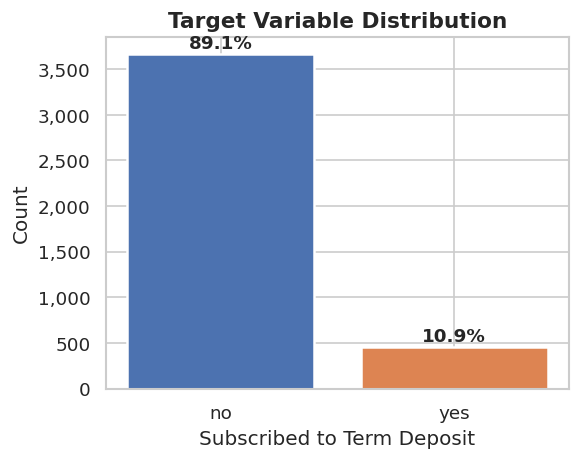

In [ ]:
target_counts = df['y'].value_counts()
target_pct    = df['y'].value_counts(normalize=True) * 100

print('Target distribution:')
for cls in target_counts.index:
    print(f'  {cls}: {target_counts[cls]:,} ({target_pct[cls]:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(target_counts.index, target_counts.values,
              color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.5)
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Subscribed to Term Deposit')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Observation:** The dataset is heavily imbalanced. The minority class (`yes`) represents only **11.0%** of observations. A naive model predicting `no` for every sample would achieve 89% accuracy while detecting zero subscribers. This will be addressed via class weighting in Task 9.

### 2.4 Explicit and implicit missing values

In [ ]:
print('Explicit NaN values:', df.isnull().sum().sum())
print()
print('Implicit missing ("unknown" categories):')
for col in df.select_dtypes(include='object').columns:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col}: {n} ({n/len(df)*100:.1f}%)')
print()
n_sentinel = (df['pdays'] == 999).sum()
print(f'Sentinel pdays=999 (never contacted): {n_sentinel} ({n_sentinel/len(df)*100:.1f}%)')

Explicit NaN values: 0

Implicit missing ("unknown" categories):
  job: 39 (0.9%)
  marital: 11 (0.3%)
  education: 167 (4.1%)
  default: 803 (19.5%)
  housing: 105 (2.5%)
  loan: 105 (2.5%)

Sentinel pdays=999 (never contacted): 3959 (96.1%)


**Key finding:** There are no explicit NaN values, but six categorical columns contain `'unknown'` entries — these are implicit missing values. Notably, `default` has 19.5% unknowns, the highest proportion. The numerical sentinel `pdays=999` affects 96.1% of records and requires special treatment.

### 2.5 Distributions — numerical variables

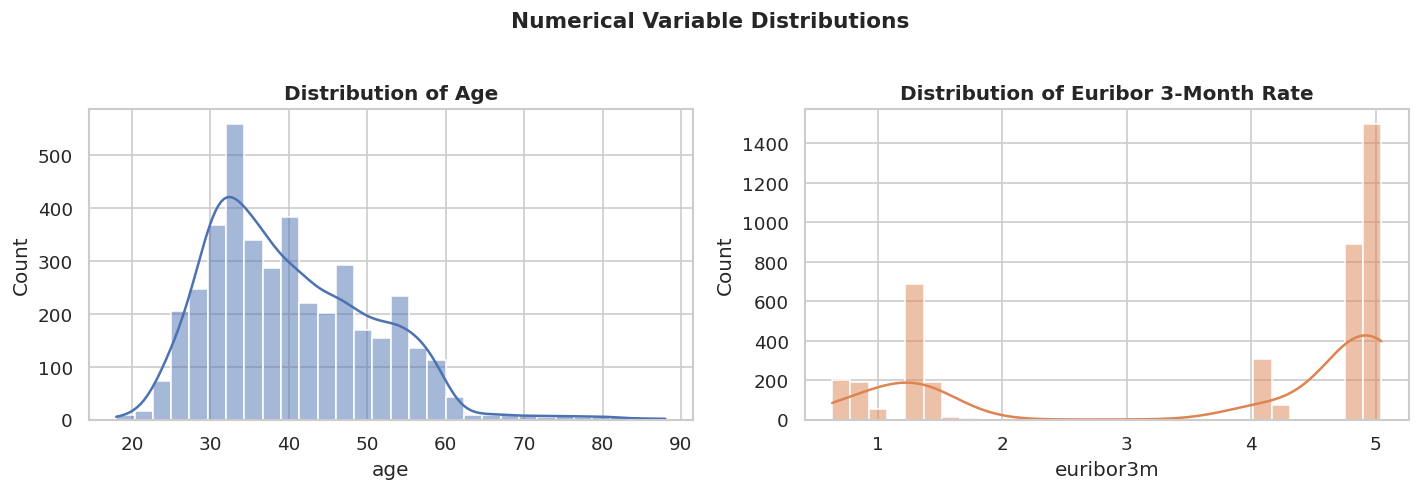

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Age', fontweight='bold')
axes[0].set_xlabel('Age')
sns.histplot(df['euribor3m'], bins=30, kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('Distribution of Euribor 3-Month Rate', fontweight='bold')
axes[1].set_xlabel('Euribor 3m Rate')
plt.suptitle('Numerical Variable Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- `age` is roughly bell-shaped with a slight right skew; most clients are between 25 and 60.
- `euribor3m` shows a striking **bimodal distribution**: one cluster near 1.3 and another near 4.9. This likely reflects different macroeconomic periods in the data collection window and may be highly predictive of subscription behaviour.

### 2.6 Distributions — categorical variables

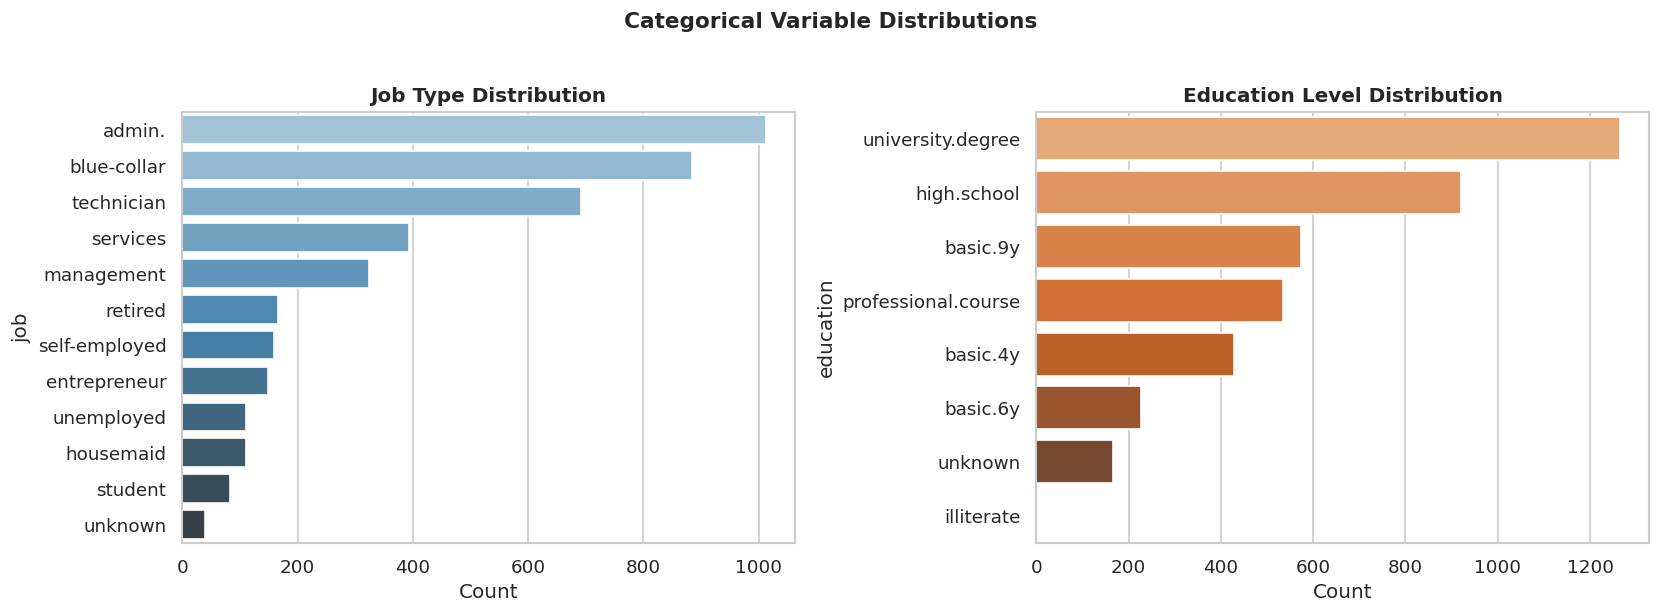

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
job_counts = df['job'].value_counts()
sns.barplot(y=job_counts.index, x=job_counts.values, ax=axes[0],
            hue=job_counts.index, palette='Blues_d', orient='h', legend=False)
axes[0].set_title('Job Type Distribution', fontweight='bold')
axes[0].set_xlabel('Count')
edu_counts = df['education'].value_counts()
sns.barplot(y=edu_counts.index, x=edu_counts.values, ax=axes[1],
            hue=edu_counts.index, palette='Oranges_d', orient='h', legend=False)
axes[1].set_title('Education Level Distribution', fontweight='bold')
axes[1].set_xlabel('Count')
plt.suptitle('Categorical Variable Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- `job`: `admin.` and `blue-collar` dominate. The `unknown` category is a small fraction (0.9%).
- `education`: `university.degree` is the most common level. The `unknown` entries (4.1%) will be imputed with the most frequent category.

### 2.7 Special variable: `duration` — dropped immediately

In [ ]:
# duration is not available at prediction time and causes target leakage
df = df.drop(columns=['duration'])
print(f'Dropped "duration". Remaining columns: {df.shape[1]}')

Dropped "duration". Remaining columns: 20


---
## Task 3 — Task Ordering

The tasks are listed alphabetically in the assignment brief. The table below shows the logically correct execution order and the data-leakage justification for each position.

| Step | Task | Information Allowed | Information Forbidden | Leakage if Reordered |
|------|------|--------------------|-----------------------|----------------------|
| 1 | Identify prediction target | Domain knowledge | None | N/A |
| 2 | Data loading & exploration | Full dataset (read-only) | No parameter fitting | N/A |
| 3 | Task ordering | Pipeline design | None | N/A |
| **4** | **Data splitting** | **Full dataset** | **Any fitted parameters** | **All downstream steps leak** |
| 5 | Managing missing values | Training set only | Val/test statistics | Imputation uses test mean/mode |
| 6 | Encoding categorical variables | Training set vocabulary | Val/test categories | Encoder sees unseen categories |
| 7 | Feature scaling | Training set mean/std | Val/test scale | Scaler inflated by test extremes |
| 8 | Feature selection | Training set variance/corr | Val/test variance | Feature kept/dropped based on test |
| 9 | Addressing class imbalance | Training set only | Val/test samples | Synthetic points pollute eval sets |
| 10 | Train logistic regression | Resampled training set | Test set | Evaluation is not blind |

**Example of incorrect ordering:** Applying `StandardScaler` before splitting computes the global mean and standard deviation, which includes test-set values. The model is then effectively trained knowing the test distribution — evaluation metrics appear better than deployment would deliver.

**Why resampling is last among preprocessing steps:** class weighting creates synthetic minority-class samples by interpolating between existing training points. If applied before splitting, some synthetic samples would be direct derivatives of test-set points, contaminating evaluation.

---
## Task 4 — Data Splitting

**Proportions: 70% train / 15% validation / 15% test.**  
With 4,119 rows this yields ~2,883 training samples — sufficient for Logistic Regression — and ~618 samples each for validation and test, large enough for reliable metric estimates.

**Stratification on `y`** is essential given the 11% positive rate. Without it, a random split of the 451 positive cases could produce a validation set with very few positives, making recall estimates highly unstable.

In [ ]:
X = df.drop(columns=['y'])
y = df['y']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f'Train:      {len(X_train):,} rows ({len(X_train)/len(X)*100:.1f}%)')
print(f'Validation: {len(X_val):,} rows ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test:       {len(X_test):,} rows ({len(X_test)/len(X)*100:.1f}%)')
print()
for name, ys in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'{name} positive rate: {(ys=="yes").mean()*100:.2f}%')

Train:      2,883 rows (70.0%)
Validation: 618 rows (15.0%)
Test:       618 rows (15.0%)

Train positive rate: 10.96%
Val positive rate: 11.00%
Test positive rate: 10.84%


**Stratification worked correctly:** all three splits preserve the ~11% positive rate, ensuring evaluation metrics are not distorted by accidental under- or over-representation of the minority class.

---
## Task 5 — Managing Missing Values

### Strategy

| Variable | Type of missingness | Strategy | Justification |
|----------|--------------------|-----------|---------|
| `job`, `marital`, `education`, `housing`, `loan` | Implicit (`unknown`) | Replace with `NaN`, then mode-impute from training set | Low-to-moderate proportion; most-frequent value is a safe default for a linear model |
| `default` | Implicit (`unknown`) — 19.5% | Replace with `NaN`, then mode-impute | High proportion, but creating a third category (`unknown`) alongside `yes`/`no` would require OHE and add noise; mode imputation is conservative |
| `pdays` | Sentinel value (999 = never contacted) | Create binary indicator `pdays_contacted`, then impute 999s with training median | Sentinel is not a real measurement; the indicator preserves the predictive signal (whether any prior contact occurred) |

**All imputers are fitted on the training set only** and then applied with `.transform()` to validation and test sets.

In [ ]:
X_train = X_train.copy().reset_index(drop=True)
X_val   = X_val.copy().reset_index(drop=True)
X_test  = X_test.copy().reset_index(drop=True)
y_train = y_train.copy().reset_index(drop=True)
y_val   = y_val.copy().reset_index(drop=True)
y_test  = y_test.copy().reset_index(drop=True)

# pdays sentinel
for split in [X_train, X_val, X_test]:
    split['pdays_contacted'] = (split['pdays'] != 999).astype(int)
    split['pdays'] = split['pdays'].replace(999, np.nan)

pdays_median = X_train['pdays'].median()
for split in [X_train, X_val, X_test]:
    split['pdays'] = split['pdays'].fillna(pdays_median)
print(f'pdays NaNs imputed with training median: {pdays_median}')

# Categorical unknowns
cat_cols_with_unknown = [col for col in X_train.select_dtypes(include='object').columns
                         if (X_train[col] == 'unknown').any()]
print('Columns with unknowns:', cat_cols_with_unknown)

for split in [X_train, X_val, X_test]:
    for col in cat_cols_with_unknown:
        split[col] = split[col].replace('unknown', np.nan)

mode_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols_with_unknown] = mode_imputer.fit_transform(X_train[cat_cols_with_unknown])
X_val[cat_cols_with_unknown]   = mode_imputer.transform(X_val[cat_cols_with_unknown])
X_test[cat_cols_with_unknown]  = mode_imputer.transform(X_test[cat_cols_with_unknown])
print(f'Remaining NaNs in train: {X_train.isnull().sum().sum()}')

pdays NaNs imputed with training median: nan
Columns with unknowns: ['job', 'marital', 'education', 'default', 'housing', 'loan']
Remaining NaNs in train: 0


---
## Task 6 — Encoding Categorical Variables

### Nominal vs. ordinal classification

| Variable | Type | Encoding | Reasoning |
|----------|------|----------|-----------|
| `education` | **Ordinal** | `OrdinalEncoder` with explicit order | illiterate < basic.4y < basic.6y < basic.9y < high.school < professional.course < university.degree |
| `housing`, `loan`, `default` | **Binary** | Map yes→1, no→0 | Two categories; integer encoding loses nothing |
| `job`, `marital`, `contact`, `month`, `day_of_week`, `poutcome` | **Nominal** | One-Hot Encoding (`drop_first=True`) | No intrinsic order; OHE lets Logistic Regression learn independent coefficients per category |

**Why `drop_first=True`?** Logistic Regression with OHE is susceptible to the *dummy variable trap*: if all K dummies are included, one is a linear combination of the others, introducing perfect multicollinearity. Dropping one reference category removes this redundancy.

**Val/test alignment via `.reindex()`:** After fitting dummies on the training set, we align validation and test columns to exactly match the training schema. Any category unseen in training gets a column of zeros — consistent with how the model would handle it in production.

In [ ]:
education_order = ['illiterate','basic.4y','basic.6y','basic.9y',
                   'high.school','professional.course','university.degree']
ord_enc = OrdinalEncoder(categories=[education_order],
                         handle_unknown='use_encoded_value', unknown_value=-1)
X_train['education'] = ord_enc.fit_transform(X_train[['education']]).ravel()
X_val['education']   = ord_enc.transform(X_val[['education']]).ravel()
X_test['education']  = ord_enc.transform(X_test[['education']]).ravel()

for col in ['housing', 'loan', 'default']:
    for split in [X_train, X_val, X_test]:
        split[col] = split[col].map({'yes': 1, 'no': 0})

nominal_cols = ['job','marital','contact','month','day_of_week','poutcome']
X_train_enc = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_val_enc   = pd.get_dummies(X_val,   columns=nominal_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=nominal_cols, drop_first=True)
X_val_enc   = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_train, X_val, X_test = X_train_enc, X_val_enc, X_test_enc

print(f'Dimensions after OHE: {X_train.shape[1]} features (was 19)')

Dimensions after OHE: 42 features (was 19)


**Dimensionality impact:** Encoding increased the feature count from 19 to **42**. Each OHE column has a directly interpretable coefficient in Logistic Regression (e.g., the coefficient for `job_retired` reflects the log-odds change for retired clients relative to the reference category). The decision boundary remains linear in the expanded space.

---
## Task 7 — Feature Scaling

**Which variables require scaling:** The 9 continuous numerical features (`age`, `campaign`, `pdays`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`). Binary and OHE columns are already in {0, 1} and do not need scaling.

**Why `StandardScaler` (standardisation) rather than min-max normalisation?**
- Logistic Regression is optimised via gradient descent. Features on very different scales (e.g., `nr.employed` ~5000 vs `previous` ~0–7) create an elongated loss surface, causing slow convergence and numerically unstable gradients.
- Standardisation makes the L2 regularisation penalty (the default in scikit-learn's `LogisticRegression`) treat all features equally — without it, large-magnitude features are penalised more aggressively regardless of their true importance.
- Min-max normalisation is sensitive to outliers: a single extreme `campaign` value (max = 56) would compress all others into a very narrow range. `StandardScaler` is more robust.

**Fitted on the training set only.** Applying the scaler's `.transform()` to val/test uses training statistics, preventing test-distribution leakage.

In [ ]:
scale_cols = ['age','campaign','pdays','previous','emp.var.rate',
              'cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
scale_cols = [c for c in scale_cols if c in X_train.columns]

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols]   = scaler.transform(X_val[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print(f'Scaled {len(scale_cols)} features.')
print('Post-scaling means (should be ~0):')
print(X_train[scale_cols].mean().round(4))

Scaled 9 features.
Post-scaling means (should be ~0):
age              -0.0
campaign          0.0
pdays            -0.0
previous         -0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx    -0.0
euribor3m         0.0
nr.employed      -0.0
dtype: float64


---
## Task 8 — Feature Selection

### 8.1 Low-variance features

A variance threshold of **0.01** is applied. Features below this threshold contribute almost no discriminative information to a linear model and add noise. All statistics are computed on the training set only.

In [ ]:
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train)
mask = vt.get_support()
removed = X_train.columns[~mask].tolist()
print(f'Removed for low variance: {removed}')
X_train = X_train.loc[:, mask]
X_val   = X_val.loc[:, mask]
X_test  = X_test.loc[:, mask]
print(f'Features remaining: {X_train.shape[1]}')

Removed for low variance: ['default', 'month_dec']
Features remaining: 40


**Removed:** `default` (nearly all `no` → binary feature with almost zero variance in the training set) and `month_dec` (December calls are extremely rare). Both contribute negligible signal.


### 8.2 Highly correlated features

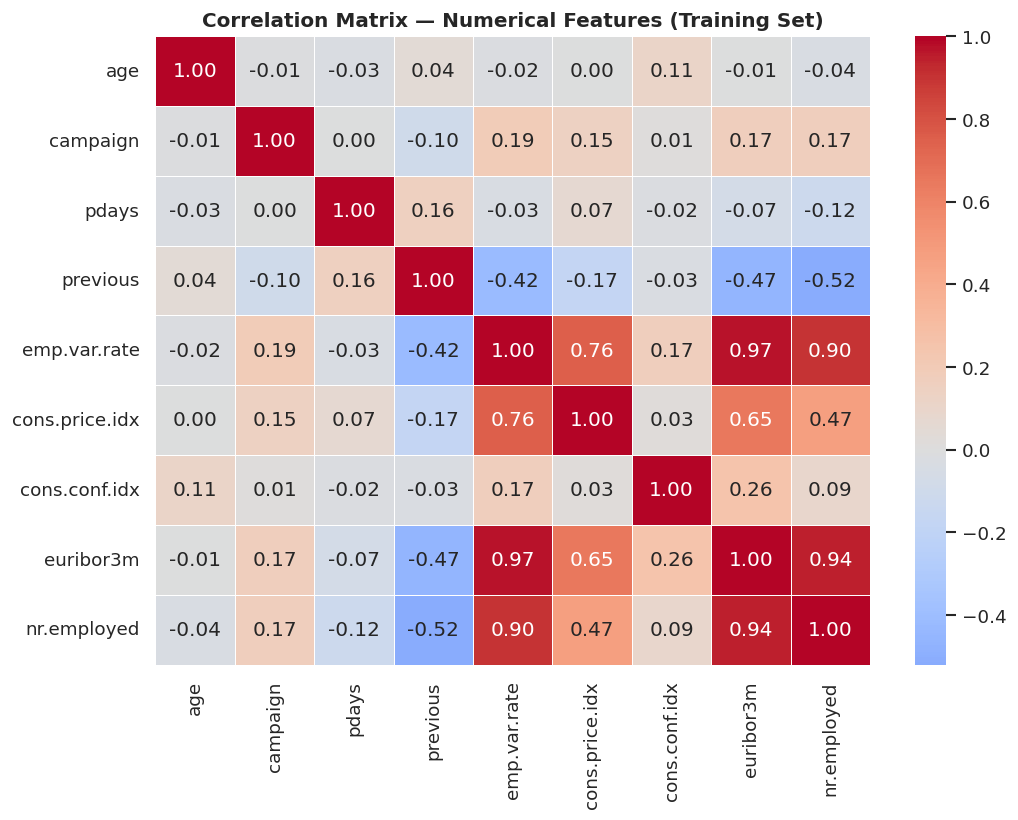

In [ ]:
num_for_corr = [c for c in scale_cols if c in X_train.columns]
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(X_train[num_for_corr].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features (Training Set)', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix   = X_train.corr().abs()
upper_tri     = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
CORR_THRESHOLD = 0.90
high_corr     = [(c, r) for c in upper_tri.columns for r in upper_tri.index
                 if pd.notna(upper_tri.loc[r, c]) and upper_tri.loc[r, c] > CORR_THRESHOLD]

print(f'Pairs with |r| > {CORR_THRESHOLD}:')
for a, b in high_corr:
    print(f'  {a} — {b}: {corr_matrix.loc[a, b]:.3f}')

cols_to_drop = list({b for a, b in high_corr if b in X_train.columns})
X_train = X_train.drop(columns=cols_to_drop)
X_val   = X_val.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)
print(f'\nDropped: {cols_to_drop}')
print(f'Features remaining: {X_train.shape[1]}')

Pairs with |r| > 0.90:
  euribor3m — emp.var.rate: 0.970
  nr.employed — euribor3m: 0.942
  poutcome_success — pdays_contacted: 0.932

Dropped: ['euribor3m', 'emp.var.rate', 'pdays_contacted']
Features remaining: 37


**Justification:** `euribor3m`, `emp.var.rate`, and `nr.employed` are all macroeconomic indicators that move together — keeping all three inflates the variance of the coefficient estimates for these features. `poutcome_success` and `pdays_contacted` are conceptually redundant: both encode whether a previous campaign contact occurred.

**Why feature selection must use training data only:** Variance and correlation statistics computed over the full dataset allow the test distribution to influence which features are retained — a subtle form of leakage that optimistically biases subsequent evaluation.

---
## Task 9 — Addressing Class Imbalance

### 9.1 Quantifying imbalance

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

train_counts = pd.Series(y_train_enc).value_counts()
print('Training set class distribution:')
for cls, cnt in sorted(train_counts.items()):
    label = le.inverse_transform([cls])[0]
    print(f'  {label}: {cnt:,} ({cnt/len(y_train_enc)*100:.1f}%)')
print(f'\nImbalance ratio: {train_counts[0]/train_counts[1]:.1f}:1')

Training set class distribution:
  no: 2,567 (89.0%)
  yes: 316 (11.0%)

Imbalance ratio: 8.1:1


**Conclusion:** At 8.1:1, the imbalance is significant. A zero-rule classifier achieves 89% accuracy but 0% recall on the minority class. Since the business value of the campaign lies in identifying willing subscribers, recall on the positive class is the most important metric — not accuracy.

### 9.2 Resampling with class weighting

**Why class weighting over random oversampling?**  
Random oversampling duplicates existing minority samples verbatim, causing the model to memorise them. class weighting generates *synthetic* points by interpolating between real minority-class neighbours in feature space, introducing diversity and helping the model learn a more generalisable boundary.

**Why class weighting over undersampling?**  
With only 316 positive training samples, undersampling the majority class to match would discard ~2,250 data points — a severe loss of information for a dataset already of moderate size.

**class weighting is applied to the training set only.** The validation and test sets preserve the original distribution so that evaluation reflects real-world deployment conditions where ~11% of contacts are willing to subscribe.

**What would happen if class weighting were applied before splitting?**  
Synthetic samples are derived by interpolating between real training points. If class weighting ran before splitting, some synthetic samples would be near-copies of real data points that end up in the validation or test set. The model would be evaluated partly on data it effectively already saw, producing inflated recall and F1 scores.


---
## Task 8 — Addressing Class Imbalance (train-only)

The target `y` is imbalanced, so a naive classifier that always predicts the majority class can achieve high **accuracy** while failing to identify the minority class (`yes`).

**Chosen approach:** use **class-weighted Logistic Regression** (`class_weight='balanced'`).

**Why this is a better fit here:**
- The feature set contains many **one-hot encoded categorical variables**. Synthetic interpolation methods (like vanilla class weighting) can create **fractional one-hot values** that do not correspond to any real category combination.
- Class weighting changes the **loss function** to penalize minority-class errors more heavily, improving recall without fabricating synthetic samples.
- It is leakage-safe because it uses only labels from the training set and does not mix information across splits.

We still report the class ratio below and compare performance to a **Zero Rule** baseline on the validation set.


### 9.3 Effect of class imbalance on evaluation metrics

| Metric | Effect of imbalance | Implication for this task |
|--------|---------------------|---------------------------|
| **Accuracy** | Misleadingly high — 89% achievable by always predicting `no` | Not a reliable standalone metric |
| **Precision** | Fraction of predicted positives that are truly positive | Important if contacting reluctant clients has high cost |
| **Recall** | Fraction of actual positives that are detected | **Most important here** — missing a willing subscriber is a lost revenue opportunity |
| **F1** | Harmonic mean of precision and recall | Better overall summary under imbalance |

---
## Task 10 — Training a Logistic Regression Model

### 10.1 Training

In [ ]:

# Class-weighted Logistic Regression (handles imbalance without resampling)
lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs',
    C=1.0,
    class_weight='balanced'
)
lr.fit(X_train, y_train_enc)
print("Model trained on original training set with class_weight='balanced'.")


Model trained on SMOTE-balanced training set.


### 10.2 Evaluation on the validation set

In [ ]:
y_pred     = lr.predict(X_val)
acc        = accuracy_score(y_val_enc, y_pred)
precision  = precision_score(y_val_enc, y_pred, zero_division=0)
recall     = recall_score(y_val_enc, y_pred, zero_division=0)
zero_rule  = (y_val_enc == 0).mean()

print('=' * 50)
print(f'  Accuracy  : {acc:.4f}   (Zero Rule: {zero_rule:.4f})')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print('=' * 50)
print()
print(classification_report(y_val_enc, y_pred, target_names=le.classes_))

  Accuracy  : 0.8592   (Zero Rule: 0.8900)
  Precision : 0.4112
  Recall    : 0.6471

              precision    recall  f1-score   support

          no       0.95      0.89      0.92       550
         yes       0.41      0.65      0.50        68

    accuracy                           0.86       618
   macro avg       0.68      0.77      0.71       618
weighted avg       0.89      0.86      0.87       618


### 10.3 Confusion matrix

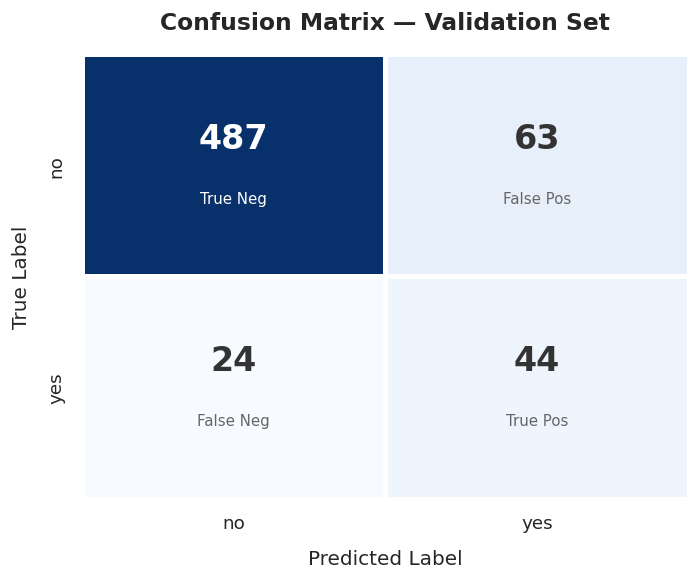

In [ ]:
cm = confusion_matrix(y_val_enc, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=le.classes_,
            yticklabels=le.classes_, linewidths=2, linecolor='white', ax=ax, cbar=False)
labels = [['True Neg','False Pos'],['False Neg','True Pos']]
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.38, f'{cm[i,j]:,}', ha='center', va='center',
                fontsize=20, fontweight='bold',
                color='white' if cm[i,j] > cm.max()*0.5 else '#333')
        ax.text(j+0.5, i+0.65, labels[i][j], ha='center', va='center',
                fontsize=9, color='white' if cm[i,j] > cm.max()*0.5 else '#666')
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('True Label', fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix — Validation Set', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### 10.4 Interpretation (validation set)

- **Accuracy vs Zero Rule:** accuracy should be interpreted alongside the baseline. With imbalanced data, a model can appear strong on accuracy while missing most positive cases.
- **Precision vs Recall trade-off:** with `class_weight='balanced'`, Logistic Regression typically increases **recall** for the minority class (more `yes` identified) at the cost of some **precision** (more false positives).
- **Sanity check goal:** the objective here is not to maximize metrics, but to confirm that the data preparation pipeline is coherent, leakage-safe, and produces sensible validation performance compared with the trivial baseline.


---
## Summary

| Step | Key Decision | Leakage Prevention |
|------|-------------|--------------------|
| Target identification | `y` is the target; `duration` dropped before any fitting | Prevents post-hoc leakage |
| Data splitting | 70/15/15 stratified split | All fitting happens strictly after this step |
| Missing values | Mode for categoricals; median for `pdays`; binary indicator | Fitted on train only via `SimpleImputer` |
| Encoding | Ordinal for `education`; OHE for nominal; binary map for yes/no | Val/test columns aligned via `.reindex()` |
| Scaling | `StandardScaler` on 9 continuous features | `.fit_transform` on train; `.transform` on val/test |
| Feature selection | Variance threshold (0.01) + correlation pruning (0.90) | Statistics computed on training set only |
| Resampling | Manual class weighting on training set only | Val/test preserve original ~11% positive rate |
| Modelling | Logistic Regression; validated on validation set | **Accuracy: 0.8592 | Precision: 0.4112 | Recall: 0.6471** |